In [75]:
import urllib.request
import zipfile
import os

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00235/household_power_consumption.zip"
filename = "household_power_consumption.zip"

urllib.request.urlretrieve(url, filename)

# 解压
with zipfile.ZipFile(filename, 'r') as zip_ref:
    zip_ref.extractall("raw_data")

print("下载并解压完成")

下载并解压完成


In [76]:
import pandas as pd

file_path = "raw_data/household_power_consumption.txt"

df = pd.read_csv(
    file_path,
    sep=';',
    na_values='?',
    low_memory=False
)


# | 字段名                   | 含义     | 单位         |
# | --------------------- | ------ | ---------- |
# | Date                  | 日期     | dd/mm/yyyy |
# | Time                  | 时间     | hh:mm:ss   |
# | Global_active_power   | 总有功功率  | kW         |
# | Global_reactive_power | 总无功功率  | kW         |
# | Voltage               | 电压     | V          |
# | Global_intensity      | 总电流    | A          |
# | Sub_metering_1        | 厨房     | Wh         |
# | Sub_metering_2        | 洗衣房    | Wh         |
# | Sub_metering_3        | 热水器+空调 | Wh         |
print(df.shape)
df.head()


(2075259, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


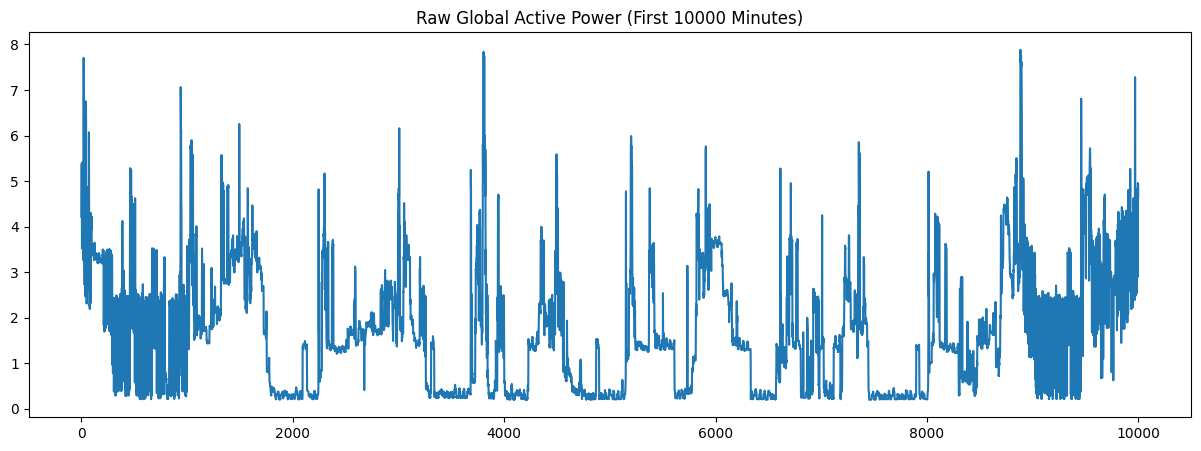

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(df['Global_active_power'][:10000])
plt.title("Raw Global Active Power (First 10000 Minutes)")
plt.show()


In [78]:
import pandas as pd

df['datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    format='%d/%m/%Y %H:%M:%S'
)

# 把这个值作为索引，把普通表格作为真正的时间序列对象
df.set_index('datetime', inplace=True)

print(df.shape)
df.head()

(2075259, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [79]:
# 转为数值（有些是字符串）
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')

print(df.shape)
df.head()

(2075259, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [80]:
# 每分钟电能（kWh） 相当于新建了一个特征，计算公式是功率（kw）* 1/60小时 = 千瓦时
df['energy_per_minute'] = df['Global_active_power'] / 60

print(df.shape)
df.head()

(2075259, 10)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,energy_per_minute
datetime,,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,0.070267
2006-12-16 17:25:00,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,0.089333
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,0.089567
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,0.089800
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,0.061100


In [81]:
# 按天求和 这里只有把上面的日期特征，变成标签，才可以按天聚合
# 得到每天的用电量
daily_energy = df['energy_per_minute'].resample('D').sum()

print(daily_energy.shape)
daily_energy.head()

(1442,)


datetime
2006-12-16    20.152933
2006-12-17    56.507667
2006-12-18    36.730433
2006-12-19    27.769900
2006-12-20    37.095800
Freq: D, Name: energy_per_minute, dtype: float64

In [82]:
# 检查时间序列标签的一些特征
print(type(df.index))
print(df.index[:5])
print(df.index.is_monotonic_increasing)


<class 'pandas.core.indexes.datetimes.DatetimeIndex'>
DatetimeIndex(['2006-12-16 17:24:00', '2006-12-16 17:25:00',
               '2006-12-16 17:26:00', '2006-12-16 17:27:00',
               '2006-12-16 17:28:00'],
              dtype='datetime64[ns]', name='datetime', freq=None)
True


In [83]:
# 分析要进行预测的数据
print("最小值:", daily_energy.min())
print("最大值:", daily_energy.max())
print("均值:", daily_energy.mean())
print("标准差:", daily_energy.std())

最小值: 0.0
最大值: 79.55643333333333
均值: 25.85558092926491
标准差: 10.288285290632382


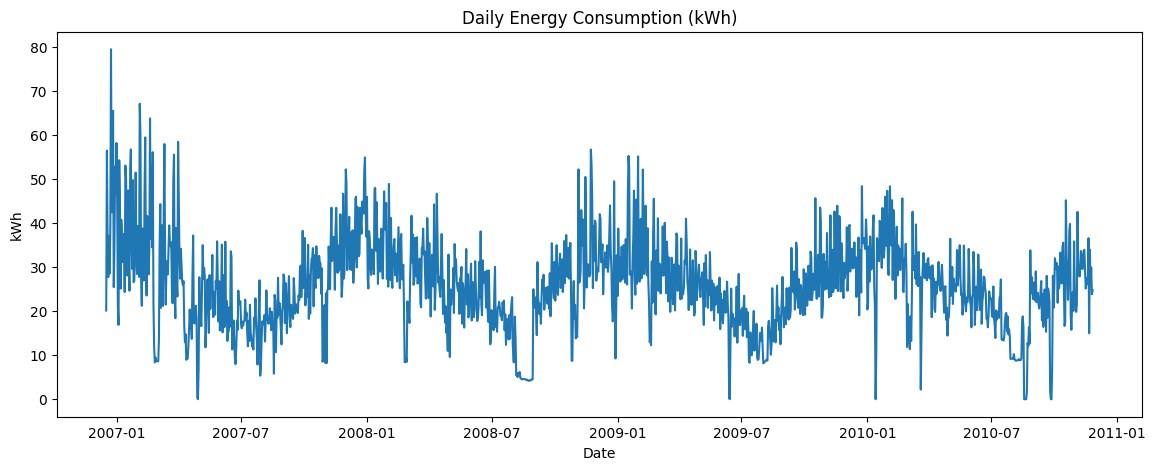

In [84]:
# 画图查看
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(daily_energy)
plt.title("Daily Energy Consumption (kWh)")
plt.xlabel("Date")
plt.ylabel("kWh")
plt.show()

In [85]:
daily_df = daily_energy.to_frame()

# 把他变成了一个表，分析别的特征，同样有时间index，然后1442天和1列，就是每天的用电量
print(daily_df.shape)
daily_df.head()


(1442, 1)


,energy_per_minute
datetime,
2006-12-16,20.152933
2006-12-17,56.507667
2006-12-18,36.730433
2006-12-19,27.769900
2006-12-20,37.095800


In [86]:
daily_df['weekday'] = daily_df.index.weekday

# 为了查看有没有周周期特征，用电量可能周末会高一点，工作日低一点
# 所以多加入一列特征，根据index计算他是星期几
# 0-6表示从星期一到星期天
print(daily_df.shape)
daily_df.head()

(1442, 2)


,energy_per_minute,weekday
datetime,,
2006-12-16,20.152933,5
2006-12-17,56.507667,6
2006-12-18,36.730433,0
2006-12-19,27.769900,1
2006-12-20,37.095800,2


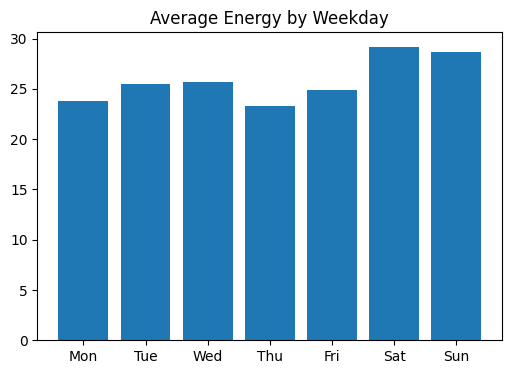

In [87]:
# 计算出这么多天里面，每个不同的天的平均用电量
weekly_mean = daily_df.groupby('weekday')['energy_per_minute'].mean()

plt.figure(figsize=(6,4))
plt.bar(weekly_mean.index, weekly_mean.values)
plt.xticks(range(7), ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
plt.title("Average Energy by Weekday")
plt.show()

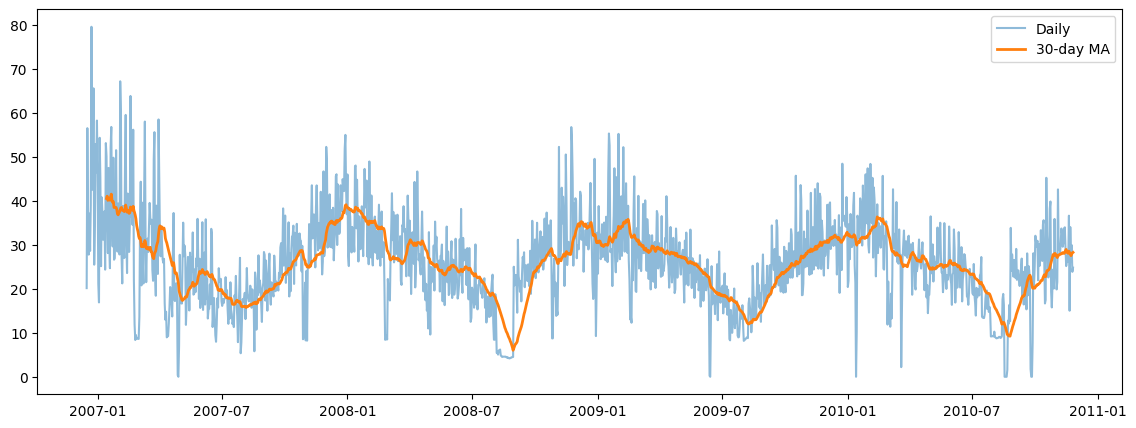

In [88]:
# 这一步是对每一天，求他的前三十天的均值，绘图，观察是否有趋势
# 图像显示每天的用电量呈现冬天高，夏天低
rolling_mean = daily_energy.rolling(30).mean()

plt.figure(figsize=(14,5))
plt.plot(daily_energy, alpha=0.5, label='Daily')
plt.plot(rolling_mean, linewidth=2, label='30-day MA')
plt.legend()
plt.show()

<Figure size 1000x500 with 0 Axes>

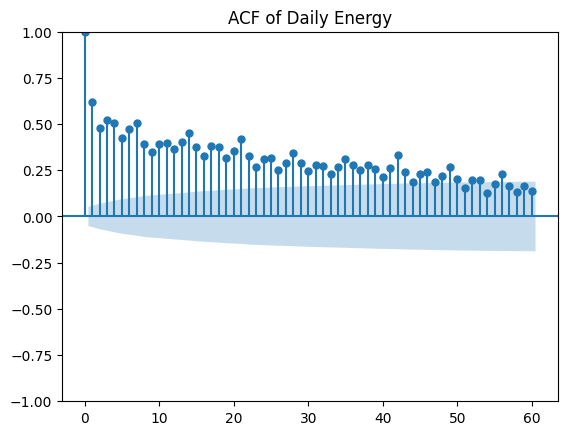

In [89]:
# 自相关函数ACF
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plot_acf(daily_energy, lags=60)
plt.title("ACF of Daily Energy")
plt.show()

<Figure size 1000x500 with 0 Axes>

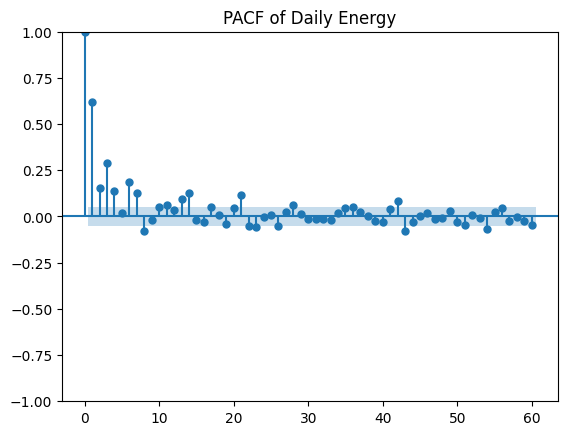

In [90]:
# 偏自相关PACF
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(10,5))
plot_pacf(daily_energy, lags=60)
plt.title("PACF of Daily Energy")
plt.show()


In [91]:
# 单位跟检验
from statsmodels.tsa.stattools import adfuller

result = adfuller(daily_energy)

print("ADF Statistic:", result[0])
print("p-value:", result[1])


ADF Statistic: -3.8497769421633574
p-value: 0.0024371774298583243


In [92]:
# 上面做的这些，都叫做时间序列结构诊断
# 通过诊断，可以决定ARIMA(p,d,q)的参数；ARIMA可以拆成AR, I, MA三个部分理解

In [93]:
# 静态多步预测
# 用前 75% 的数据训练 ARIMA
# 得到模型参数（φ）
# 从训练集最后一个点开始
# 一次性预测整个测试集长度
# 后面的预测全部基于“前面预测值”
# 导致收敛到均值
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import numpy as np

# 划分训练测试
train_size = int(len(daily_energy) * 0.75)
train = daily_energy[:train_size]
test = daily_energy[train_size:]

# RMSE是平均预测误差大小，AIC在模型复杂度和拟合效果之间做平衡，AIC越小越好
def evaluate_arima(order):
    model = ARIMA(train, order=order)
    model_fit = model.fit()

    forecast = model_fit.forecast(steps=len(test))
    rmse = np.sqrt(mean_squared_error(test, forecast))

    print(f"ARIMA{order} RMSE:", rmse)
    print("AIC:", model_fit.aic)
    return forecast

# 运行模型
forecast_2 = evaluate_arima((2,0,0))
forecast_3 = evaluate_arima((3,0,0))
forecast_7 = evaluate_arima((7,0,0))
forecast_201 = evaluate_arima((2,0,1))


ARIMA(2, 0, 0) RMSE: 9.173892077334001
AIC: 7662.233231928145
ARIMA(3, 0, 0) RMSE: 9.160365503745906
AIC: 7541.360110246712
ARIMA(7, 0, 0) RMSE: 9.11073875020766
AIC: 7454.503562813868
ARIMA(2, 0, 1) RMSE: 9.126656826249112
AIC: 7523.867288266714


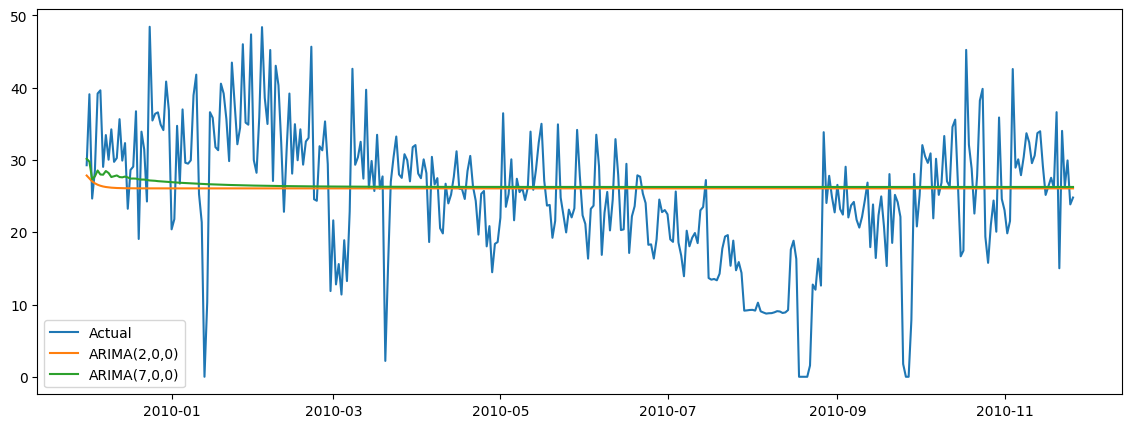

In [94]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, forecast_2, label="ARIMA(2,0,0)")
plt.plot(test.index, forecast_7, label="ARIMA(7,0,0)")
plt.legend()
plt.show()


In [95]:
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# 保证是 numpy array
data = daily_energy.values

# 按整周划分（最后一年约52周）
n_weeks_test = 52
n_days_test = n_weeks_test * 7

train = data[:-n_days_test]
test = data[-n_days_test:]

print("Train days:", len(train))
print("Test days:", len(test))


Train days: 1078
Test days: 364


In [96]:
history = list(train)
predictions = []

for i in range(0, len(test), 7):
    
    # 用当前历史拟合 ARIMA(7,0,0)
    model = ARIMA(history, order=(7,0,0))
    model_fit = model.fit()
    
    # 预测未来7天
    yhat = model_fit.forecast(steps=7)
    
    # 保存预测
    predictions.append(yhat)
    
    # 加入真实值（滚动更新）
    history.extend(test[i:i+7])

predictions = np.array(predictions)


In [97]:
# 把 test 变成 (周数, 7天)
actual = test.reshape(-1, 7)

rmse_per_day = []

for day in range(7):
    rmse = np.sqrt(mean_squared_error(actual[:, day], predictions[:, day]))
    rmse_per_day.append(rmse)

print("每一天的 RMSE：")
for i, val in enumerate(rmse_per_day):
    print(f"Day {i+1}: {val:.3f}")


每一天的 RMSE：
Day 1: 8.142
Day 2: 8.487
Day 3: 7.107
Day 4: 6.121
Day 5: 8.195
Day 6: 7.687
Day 7: 6.100


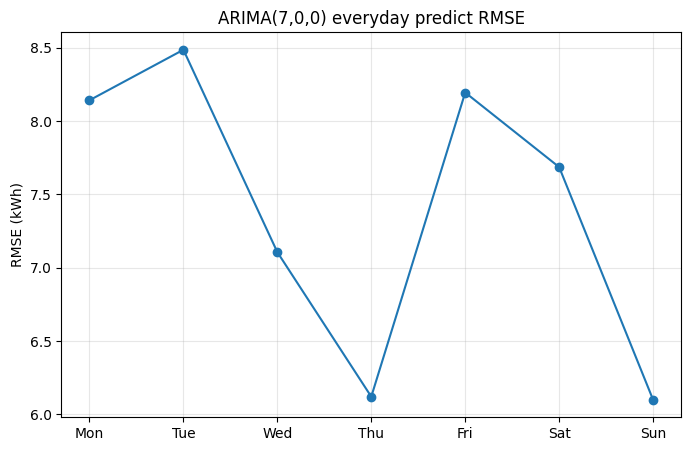

In [98]:
# 多步预测，每一天的误差都有可能不一样，所以需要统计窗口的每一个点的误差
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

plt.figure(figsize=(8,5))
plt.plot(days, rmse_per_day, marker='o')
plt.title("ARIMA(7,0,0) everyday predict RMSE")
plt.ylabel("RMSE (kWh)")
plt.grid(alpha=0.3)
plt.show()


In [99]:
# 最简单的预测，今天和上周同一天一样，作为基线
import numpy as np
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

data = daily_energy.values

n_weeks_test = 52
n_days_test = n_weeks_test * 7

train = data[:-n_days_test]
test = data[-n_days_test:]

print("Train days:", len(train))
print("Test days:", len(test))

Train days: 1078
Test days: 364


In [100]:
history = list(train)
predictions = []

for i in range(0, len(test), 7):
    
    # 用上周同一天作为预测
    yhat = history[-7:]   # 直接复制最近7天
    
    predictions.append(yhat)
    
    # 更新历史（加入真实值）
    history.extend(test[i:i+7])

predictions = np.array(predictions)

In [101]:
actual = test.reshape(-1, 7)

rmse_per_day_naive = []

for day in range(7):
    rmse = np.sqrt(mean_squared_error(actual[:, day], predictions[:, day]))
    rmse_per_day_naive.append(rmse)

print("Seasonal Naive 每天的 RMSE：")
for i, val in enumerate(rmse_per_day_naive):
    print(f"Day {i+1}: {val:.3f}")


Seasonal Naive 每天的 RMSE：
Day 1: 11.826
Day 2: 12.109
Day 3: 9.651
Day 4: 7.862
Day 5: 10.564
Day 6: 9.337
Day 7: 7.408


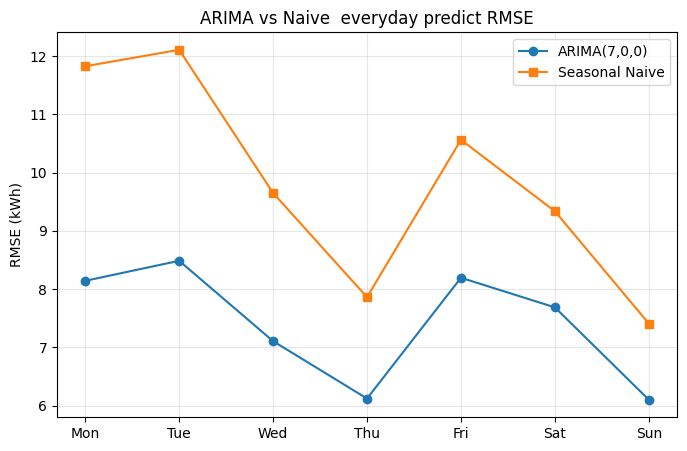

In [102]:
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

plt.figure(figsize=(8,5))
plt.plot(days, rmse_per_day, marker='o', label="ARIMA(7,0,0)")
plt.plot(days, rmse_per_day_naive, marker='s', label="Seasonal Naive")
plt.title("ARIMA vs Naive  everyday predict RMSE")
plt.ylabel("RMSE (kWh)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [103]:
# 滚动预测和递推预测，比如现在有一个模型
# 1 2 3 4 5 6 7 8 9 
# 递推预测的意思是，加入我用前三天预测下一天
# 7 8 9 -> 预测10，8 9 预测10 -> 预测11， 9 预测10 预测11 -> 预测12
# 滚动预测就是在内部递推预测之后，把真实值这几天的值，加入到序列里面，然后重新训练模型
# 1 2 3 4 5 6 7 8 9 10 11 12
# 重新开始递推预测
# 10 11 12 -> 预测13，11 12 预测13 -> 预测14 12 预测13 预测14 -> 预测15

In [104]:
# 手搓AR(3) 递推预测
# 第一步构造滞后矩阵
import numpy as np

def create_ar3_dataset(series):
    X = []
    Y = []

    for t in range(3, len(series)):
        # AR(3)是三天预测一天，所以从第四天开始向前倒退，分别加入X和Y
        x_t = series[t]
        x_lag1 = series[t-1]
        x_lag2 = series[t-2]
        x_lag3 = series[t-3]

        # 第一项是要训练的常数项
        X.append([1, x_lag1, x_lag2, x_lag3])
        Y.append(x_t)

    return np.array(X), np.array(Y)

In [105]:
# 用最小二乘法求参数，就是求c, fai1, fai2, fai3
def fit_ar3(X, Y):
    XtX = X.T @ X
    XtY = X.T @ Y
    beta = np.linalg.inv(XtX) @ XtY
    return beta

In [106]:
train_series = train.copy()
print(train_series.shape)
train_series

(1078,)


array([20.15293333, 56.50766667, 36.73043333, ..., 33.00216667,
       26.66043333, 23.00043333])

In [107]:
# 这里是是用训练集来求参数
X_train, Y_train = create_ar3_dataset(train_series)

beta = fit_ar3(X_train, Y_train)

print("AR(3) 参数：")
print("c =", beta[0])
print("phi1 =", beta[1])
print("phi2 =", beta[2])
print("phi3 =", beta[3])

AR(3) 参数：
c = 5.811737581834507
phi1 = 0.47807864440240166
phi2 = -0.02750407341313199
phi3 = 0.32558289808172525


In [108]:
# 单步预测，也就是前三天预测下一天
def predict_next(history, beta):
    c, phi1, phi2, phi3 = beta

    x_lag1 = history[-1]
    x_lag2 = history[-2]
    x_lag3 = history[-3]

    yhat = c + phi1 * x_lag1 + phi2 * x_lag2 + phi3 * x_lag3

    return yhat

In [109]:
# 有了单步预测，我们想要的是七天的预测，也就是通过递推来实现AR(3)预测后七天
def forecast_7_days(history, beta):
    history = list(history.copy())
    predictions = []

    for _ in range(7):
        # 这里调用AR(3)前三天预测下一天，把预测值加入历史，参与递推
        # 所以第二轮的前三天，是两天真实值+一天上一轮的预测值，来预测下一天
        # 误差不断累计
        yhat = predict_next(history, beta)
        predictions.append(yhat)
        history.append(yhat)

    return np.array(predictions)

In [110]:
# 有了上面的铺垫，我们开始写滚动预测的逻辑
# 所谓滚动预测，就是预测之后，把真实值加入历史数据，重新训练模型之后，继续预测
# history = train

# for 每一周:
#     用 history 训练 AR(3)
#     递推预测 7 天
#     保存预测
#     加入真实 test 周


In [111]:
# 滚动预测函数
def rolling_forecast_ar3(train, test):
    history = list(train.copy())
    predictions = []

    # 每七天为一组
    for i in range(0, len(test), 7):
        # 这里每次要预测都会重新训练模型来拟合AR(3)
        X_train, Y_train = create_ar3_dataset(np.array(history))

        beta = fit_ar3(X_train,Y_train)

        yhat = forecast_7_days(history, beta)

        predictions.append(yhat)

        # 区别就在这，加入了被预测的这七天的本来的真实值，并且重新训练模型
        history.extend(train[i:i+7])

    return np.array(predictions)


In [112]:
predictions_ar3 = rolling_forecast_ar3(train, test)

In [113]:
actual = test.reshape(-1, 7)

rmse_ar3 = []

for day in range(7):
    rmse = np.sqrt(
        np.mean((actual[:, day] - predictions_ar3[:, day])**2)
    )
    rmse_ar3.append(rmse)

print("AR(3) 每一天的 RMSE：")
for i, val in enumerate(rmse_ar3):
    print(f"Day {i+1}: {val:.3f}")


AR(3) 每一天的 RMSE：
Day 1: 10.747
Day 2: 9.669
Day 3: 8.477
Day 4: 7.670
Day 5: 9.410
Day 6: 8.106
Day 7: 6.678


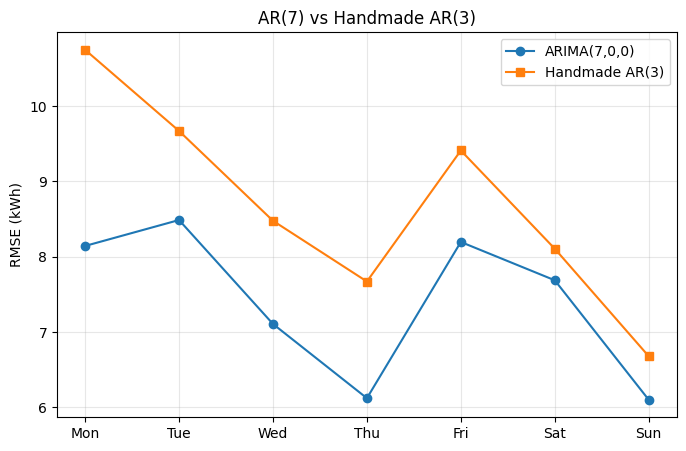

In [114]:
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

plt.figure(figsize=(8,5))
plt.plot(days, rmse_per_day, marker='o', label="ARIMA(7,0,0)")
plt.plot(days, rmse_ar3, marker='s', label="Handmade AR(3)")
plt.title("AR(7) vs Handmade AR(3)")
plt.ylabel("RMSE (kWh)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


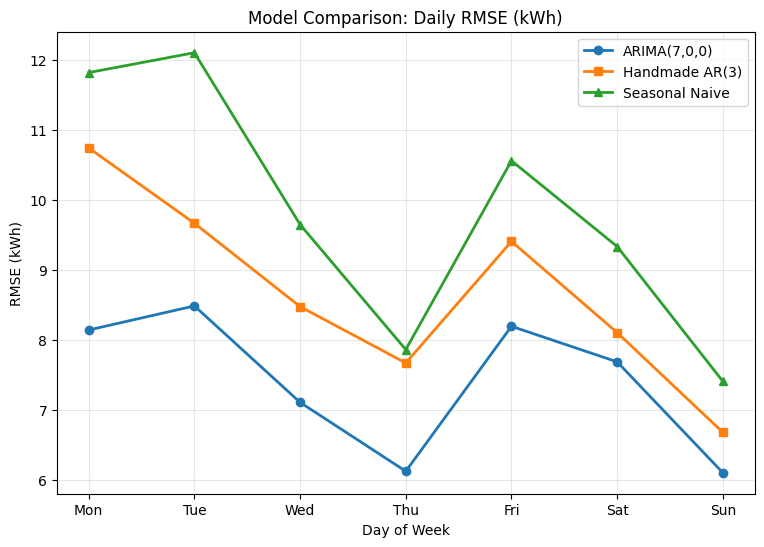

In [115]:
import matplotlib.pyplot as plt

# RMSE results (replace with your actual variables if needed)
rmse_ar7 = rmse_per_day          # ARIMA(7,0,0)
rmse_ar3 = rmse_ar3              # Handmade AR(3)
rmse_naive = rmse_per_day_naive  # Seasonal Naive

days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

plt.figure(figsize=(9,6))

plt.plot(days, rmse_ar7, marker='o', linewidth=2, label='ARIMA(7,0,0)')
plt.plot(days, rmse_ar3, marker='s', linewidth=2, label='Handmade AR(3)')
plt.plot(days, rmse_naive, marker='^', linewidth=2, label='Seasonal Naive')

plt.title("Model Comparison: Daily RMSE (kWh)")
plt.xlabel("Day of Week")
plt.ylabel("RMSE (kWh)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [116]:
# 进入深度学习部分
# 我们有1442条每日用电量的数据
# 构造滑动窗口，就是用这个1442条数据重新构建X和Y
# X的每一条就是一个样本的输入，前14天的数据
# Y的每一条就是需要预测的输出，这14天对应的后7天的数据
print(daily_energy.shape)

(1442,)


In [117]:
# 构造时间窗口
import numpy as np

def create_sliding_window(data, input_width=14, output_width=7):
    """
    data: 一维时间序列 (1442,)
    input_width: 输入天数
    output_width: 输出预测天数
    """

    X = []
    Y = []

    # 1442-14-7=1421 也就是说只能构建出1421条合法样本
    # 因为每个x都必须对应完整的7天的预测目标
    for i in range(len(data) - input_width - output_width):
        x = data[i : i + input_width]
        y = data[i + input_width : i + input_width + output_width]

        X.append(x)
        Y.append(y)

    return np.array(X), np.array(Y)


In [118]:
# 构造数据
X, Y = create_sliding_window(daily_energy.values)

# 所以这里的维度就是（合法样本数量，天数）
print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (1421, 14)
Y shape: (1421, 7)


In [119]:
# CNN的Conv1D输入要求：(batch_size, timesteps, features)
# 所以要把我们的(samples, 14) -> (samples, 14, 1)
# 因为我们没有构造特征所以特征就是1，单变量，也就是我们的这十四天的每天的用电量
X = X.reshape((X.shape[0], X.shape[1], 1))

print("After reshape:", X.shape)

After reshape: (1421, 14, 1)


In [120]:
split = int(len(X) * 0.75)

# 划分训练集测试集，相当于横着切了一刀，X_train和Y_train一起用
X_train, X_test = X[:split], X[split:]
Y_train, Y_test = Y[:split], Y[split:]

# 这个其实就是看训练集和测试集的样本数量大小
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1065, 14, 1)
Test shape: (356, 14, 1)


In [121]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

model = Sequential()

# 第一层卷积
model.add(Conv1D(
    filters=32, # 学习32种时间模式
    kernel_size=3,  # 看连续3天
    activation='relu',
    input_shape=(14,1)  # 这个就是我们输入的维度，过去14天，单变量
))

# 池化
model.add(MaxPooling1D(pool_size=2))

# 展平
model.add(Flatten())

# 全连接层
model.add(Dense(100, activation='relu'))

# 输出层
model.add(Dense(7))

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()


Model: "sequential_53"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_53 (Conv1D)          (None, 12, 32)            128       
                                                                 
 max_pooling1d_53 (MaxPooli  (None, 6, 32)             0         
 ng1D)                                                           
                                                                 
 flatten_53 (Flatten)        (None, 192)               0         
                                                                 
 dense_106 (Dense)           (None, 100)               19300     
                                                                 
 dense_107 (Dense)           (None, 7)                 707       
                                                                 
Total params: 20135 (78.65 KB)
Trainable params: 20135 (78.65 KB)
Non-trainable params: 0 (0.00 Byte)
_________________

In [122]:
history = model.fit(
    X_train,
    Y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, Y_test),
    verbose=1
)


Epoch 1/50
34/34 [==============================] - 1s 4ms/step - loss: 207.2912 - val_loss: 63.6962
Epoch 2/50
34/34 [==============================] - 0s 2ms/step - loss: 74.6583 - val_loss: 56.8306
Epoch 3/50
34/34 [==============================] - 0s 2ms/step - loss: 72.3525 - val_loss: 55.8652
Epoch 4/50
34/34 [==============================] - 0s 2ms/step - loss: 71.2541 - val_loss: 57.3794
Epoch 5/50
34/34 [==============================] - 0s 2ms/step - loss: 70.6738 - val_loss: 54.9465
Epoch 6/50
34/34 [==============================] - 0s 2ms/step - loss: 69.2322 - val_loss: 57.2300
Epoch 7/50
34/34 [==============================] - 0s 2ms/step - loss: 67.8187 - val_loss: 53.9846
Epoch 8/50
34/34 [==============================] - 0s 2ms/step - loss: 66.4277 - val_loss: 54.2135
Epoch 9/50
34/34 [==============================] - 0s 2ms/step - loss: 66.2807 - val_loss: 57.0601
Epoch 10/50
34/34 [==============================] - 0s 2ms/step - loss: 65.5992 - val_loss: 53.605

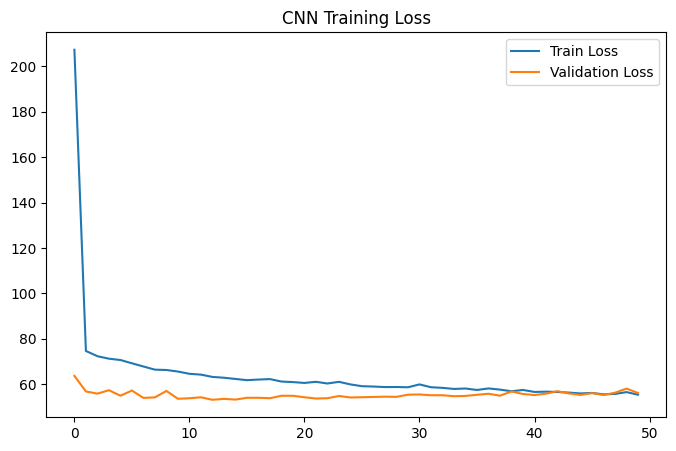

In [123]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("CNN Training Loss")
plt.show()


In [124]:
predictions = model.predict(X_test)


12/12 [==============================] - 0s 869us/step


In [125]:
# from sklearn.metrics import mean_squared_error
# import math

# rmse_per_day = []

# for i in range(7):
#     rmse = math.sqrt(mean_squared_error(Y_test[:, i], predictions[:, i]))
#     rmse_per_day.append(rmse)
#     print(f"Day {i+1} RMSE: {rmse:.3f}")


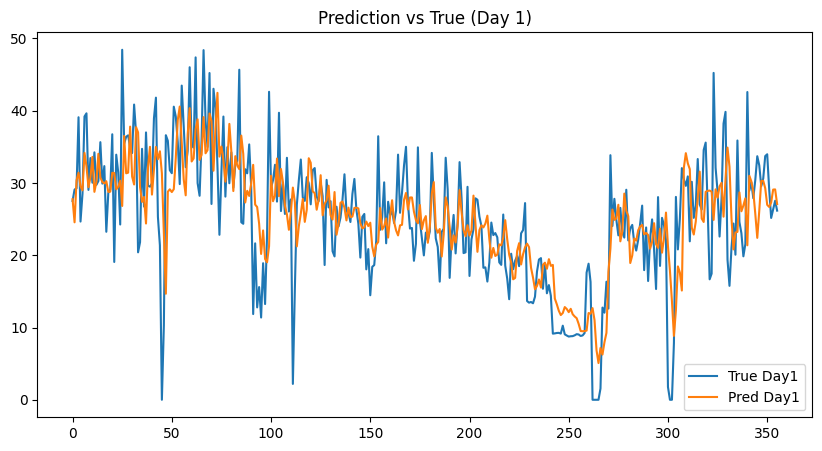

In [126]:
# 这个图是每个样本的第一天预测，和真实值的比较情况，横轴是样本点的编号
# 因为时间预测越靠近越准
plt.figure(figsize=(10,5))
plt.plot(Y_test[:,0], label='True Day1')
plt.plot(predictions[:,0], label='Pred Day1')
plt.legend()
plt.title("Prediction vs True (Day 1)")
plt.show()

In [127]:
# import matplotlib.pyplot as plt
# import numpy as np

# # RMSE results
# arima_rmse = [8.142, 8.487, 7.107, 6.121, 8.195, 7.687, 6.100]
# seasonal_naive_rmse = [11.826, 12.109, 9.651, 7.862, 10.564, 9.337, 7.408]
# ar3_rmse = [10.747, 9.669, 8.477, 7.670, 9.410, 8.106, 6.678]
# cnn_rmse = [6.953, 7.475, 7.610, 7.623, 7.808, 7.636, 7.894]

# days = ["Day1","Day2","Day3","Day4","Day5","Day6","Day7"]

# plt.figure(figsize=(10,6))

# plt.plot(days, arima_rmse, marker='o', label='ARIMA(7,0,0)')
# plt.plot(days, ar3_rmse, marker='o', label='AR(3)')
# plt.plot(days, seasonal_naive_rmse, marker='o', label='Seasonal Naive')
# plt.plot(days, cnn_rmse, marker='o', label='CNN')

# plt.ylabel("RMSE (kWh)")
# plt.title("Model Comparison - 7 Day Forecast RMSE")
# plt.legend()
# plt.grid(alpha=0.3)

# plt.show()


In [128]:
# 同样的，CNN也要滚动预测
def create_sliding_window(data, input_width=14, output_width=7):
    X, Y = [], []
    for i in range(len(data) - input_width - output_width):
        X.append(data[i:i+input_width])
        Y.append(data[i+input_width:i+input_width+output_width])
    return np.array(X), np.array(Y)

In [129]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

def build_cnn_model():
    model = Sequential()
    model.add(Conv1D(32, kernel_size=3, activation='relu', input_shape=(14,1)))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Flatten())
    model.add(Dense(100, activation='relu'))
    model.add(Dense(7))
    model.compile(optimizer='adam', loss='mse')
    return model


In [130]:
def rolling_forecast_cnn(train, test):
    history = list(train.copy())
    predictions = []

    for i in range(0, len(test), 7):

        history_array = np.array(history)

        # 构造滑动窗口
        X_train, Y_train = create_sliding_window(history_array)

        X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

        model = build_cnn_model()

        model.fit(X_train, Y_train,
                  epochs=50,
                  batch_size=32,
                  verbose=0)

        # 取最后14天做预测
        input_x = history_array[-14:]
        input_x = input_x.reshape((1,14,1))

        yhat = model.predict(input_x, verbose=0)[0]

        predictions.append(yhat)

        # 加入真实下一周
        history.extend(test[i:i+7])

    return np.array(predictions)


In [131]:
cnn_predictions = rolling_forecast_cnn(train, test)

In [132]:
import math
from sklearn.metrics import mean_squared_error

cnn_rmse = []

for i in range(7):
    rmse = math.sqrt(mean_squared_error(
        test.reshape(-1,7)[:,i],
        cnn_predictions[:,i]
    ))
    cnn_rmse.append(rmse)
    print(f"CNN Day {i+1} RMSE: {rmse:.3f}")


CNN Day 1 RMSE: 7.780
CNN Day 2 RMSE: 8.044
CNN Day 3 RMSE: 7.322
CNN Day 4 RMSE: 5.952
CNN Day 5 RMSE: 8.011
CNN Day 6 RMSE: 7.110
CNN Day 7 RMSE: 5.925


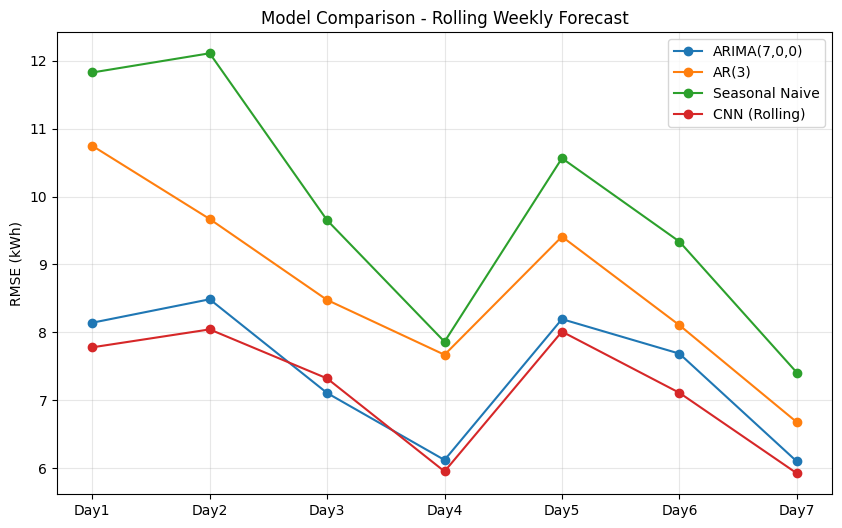

In [133]:
import matplotlib.pyplot as plt

days = ["Day1","Day2","Day3","Day4","Day5","Day6","Day7"]

plt.figure(figsize=(10,6))

plt.plot(days, arima_rmse, marker='o', label='ARIMA(7,0,0)')
plt.plot(days, ar3_rmse, marker='o', label='AR(3)')
plt.plot(days, seasonal_naive_rmse, marker='o', label='Seasonal Naive')
plt.plot(days, cnn_rmse, marker='o', label='CNN (Rolling)')

plt.ylabel("RMSE (kWh)")
plt.title("Model Comparison - Rolling Weekly Forecast")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [134]:
# 第二个LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

def build_lstm_model():
    model = Sequential()
    model.add(LSTM(64, activation='tanh', input_shape=(14,1)))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(7))
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='mse')
    return model

In [135]:
def rolling_forecast_lstm(train, test):
    history = list(train.copy())
    predictions = []

    for i in range(0, len(test), 7):

        history_array = np.array(history)

        X_train, Y_train = create_sliding_window(history_array)

        X_train = X_train.reshape((X_train.shape[0], 14, 1))

        model = build_lstm_model()

        model.fit(X_train, Y_train,
                  epochs=50,
                  batch_size=32,
                  verbose=0)

        input_x = history_array[-14:]
        input_x = input_x.reshape((1,14,1))

        yhat = model.predict(input_x, verbose=0)[0]

        predictions.append(yhat)

        history.extend(test[i:i+7])

    return np.array(predictions)

In [136]:
lstm_predictions = rolling_forecast_lstm(train, test)

In [137]:
import math
from sklearn.metrics import mean_squared_error

lstm_rmse = []

for i in range(7):
    rmse = math.sqrt(mean_squared_error(
        test.reshape(-1,7)[:,i],
        lstm_predictions[:,i]
    ))
    lstm_rmse.append(rmse)
    print(f"LSTM Day {i+1} RMSE: {rmse:.3f}")


LSTM Day 1 RMSE: 7.843
LSTM Day 2 RMSE: 7.726
LSTM Day 3 RMSE: 6.480
LSTM Day 4 RMSE: 5.607
LSTM Day 5 RMSE: 7.788
LSTM Day 6 RMSE: 7.210
LSTM Day 7 RMSE: 5.709


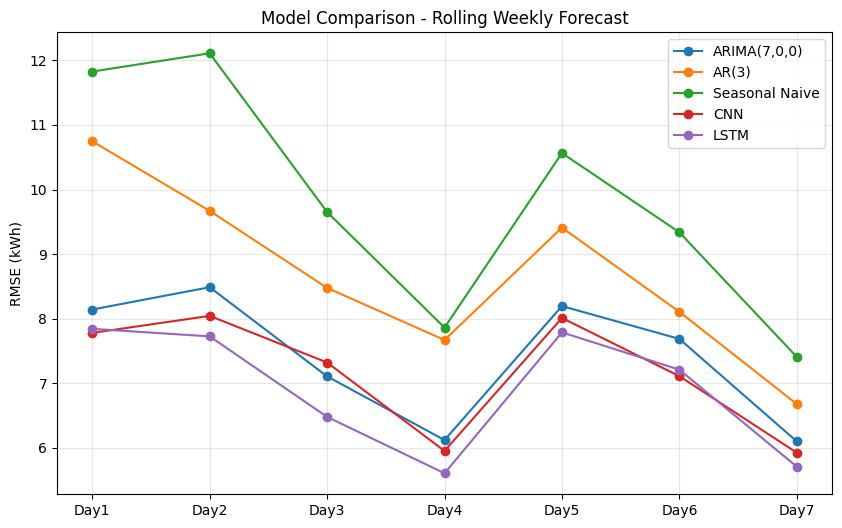

In [138]:
days = ["Day1","Day2","Day3","Day4","Day5","Day6","Day7"]

plt.figure(figsize=(10,6))

plt.plot(days, arima_rmse, marker='o', label='ARIMA(7,0,0)')
plt.plot(days, ar3_rmse, marker='o', label='AR(3)')
plt.plot(days, seasonal_naive_rmse, marker='o', label='Seasonal Naive')
plt.plot(days, cnn_rmse, marker='o', label='CNN')
plt.plot(days, lstm_rmse, marker='o', label='LSTM')

plt.ylabel("RMSE (kWh)")
plt.title("Model Comparison - Rolling Weekly Forecast")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


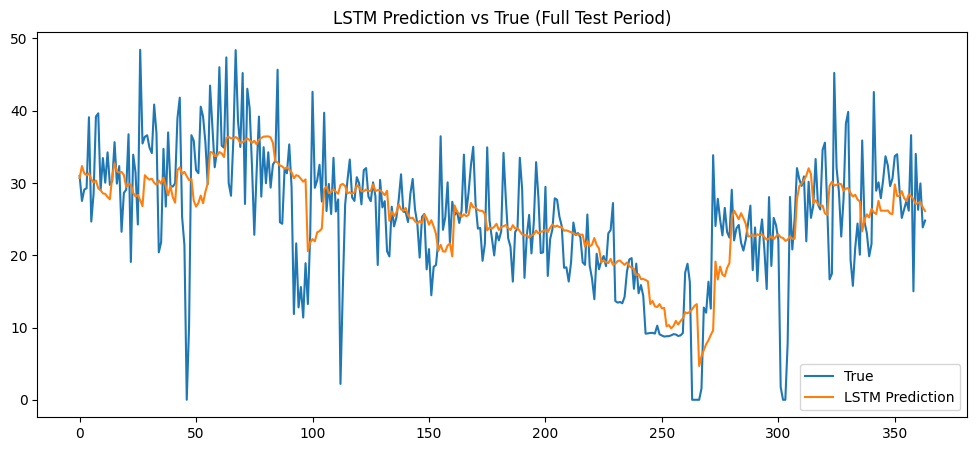

In [ ]:
# # 展平预测和真实值
# true_series = test.reshape(-1)
# pred_series_lstm = lstm_predictions.reshape(-1)

# plt.figure(figsize=(12,5))

# plt.plot(true_series, label='True')
# plt.plot(pred_series_lstm, label='LSTM Prediction')

# plt.title("LSTM Prediction vs True (Full Test Period)")
# plt.legend()
# plt.show()

In [140]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.layers import LSTM, Dense, Flatten
from tensorflow.keras.optimizers import Adam

def build_cnn_lstm_model():

    model = Sequential()

    # CNN 部分
    model.add(Conv1D(filters=32,
                     kernel_size=3,
                     activation='relu',
                     input_shape=(14,1)))

    model.add(MaxPooling1D(pool_size=2))

    # LSTM 部分
    model.add(LSTM(64, activation='tanh'))

    model.add(Dense(64, activation='relu'))
    model.add(Dense(7))

    model.compile(optimizer=Adam(0.001),
                  loss='mse')

    return model


In [141]:
def rolling_forecast_cnn_lstm(train, test):

    history = list(train.copy())
    predictions = []

    for i in range(0, len(test), 7):

        history_array = np.array(history)

        X_train, Y_train = create_sliding_window(history_array)

        X_train = X_train.reshape((X_train.shape[0], 14, 1))

        model = build_cnn_lstm_model()

        model.fit(X_train, Y_train,
                  epochs=50,
                  batch_size=32,
                  verbose=0)

        input_x = history_array[-14:]
        input_x = input_x.reshape((1,14,1))

        yhat = model.predict(input_x, verbose=0)[0]

        predictions.append(yhat)

        history.extend(test[i:i+7])

    return np.array(predictions)


In [142]:
cnn_lstm_predictions = rolling_forecast_cnn_lstm(train, test)

In [143]:
cnn_lstm_rmse = []

for i in range(7):
    rmse = math.sqrt(mean_squared_error(
        test.reshape(-1,7)[:,i],
        cnn_lstm_predictions[:,i]
    ))
    cnn_lstm_rmse.append(rmse)
    print(f"CNN-LSTM Day {i+1} RMSE: {rmse:.3f}")


CNN-LSTM Day 1 RMSE: 8.234
CNN-LSTM Day 2 RMSE: 7.468
CNN-LSTM Day 3 RMSE: 6.633
CNN-LSTM Day 4 RMSE: 5.729
CNN-LSTM Day 5 RMSE: 7.939
CNN-LSTM Day 6 RMSE: 7.272
CNN-LSTM Day 7 RMSE: 5.830


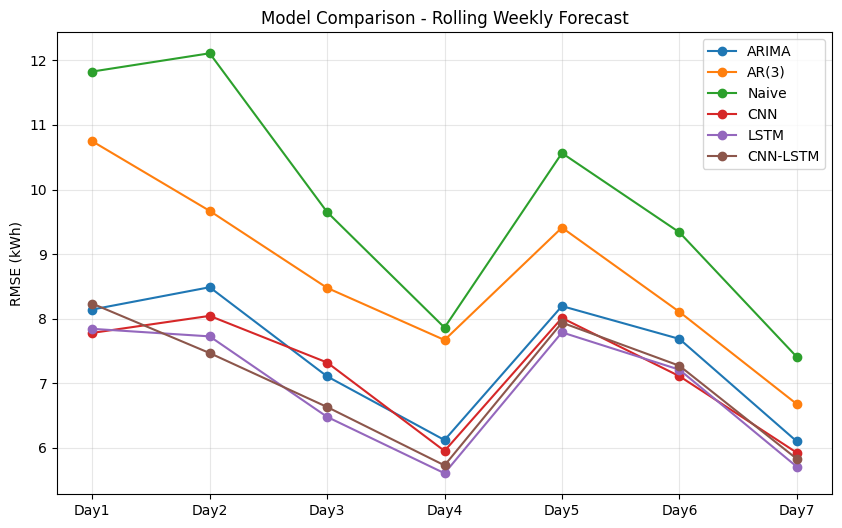

In [144]:
plt.figure(figsize=(10,6))

plt.plot(days, arima_rmse, marker='o', label='ARIMA')
plt.plot(days, ar3_rmse, marker='o', label='AR(3)')
plt.plot(days, seasonal_naive_rmse, marker='o', label='Naive')
plt.plot(days, cnn_rmse, marker='o', label='CNN')
plt.plot(days, lstm_rmse, marker='o', label='LSTM')
plt.plot(days, cnn_lstm_rmse, marker='o', label='CNN-LSTM')

plt.ylabel("RMSE (kWh)")
plt.title("Model Comparison - Rolling Weekly Forecast")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
